# Import the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("bankmarketing.csv")
df.head()
#duplicate the data
data=df.copy()

# Display the first few rows and column names
data.head(), data.columns.tolist(),data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

(   age        job  marital    education  default housing loan    contact  \
 0   56  housemaid  married     basic.4y       no      no   no  telephone   
 1   57   services  married  high.school  unknown      no   no  telephone   
 2   37   services  married  high.school       no     yes   no  telephone   
 3   40     admin.  married     basic.6y       no      no   no  telephone   
 4   56   services  married  high.school       no      no  yes  telephone   
 
   month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
 0   may         mon  ...         1    999         0  nonexistent          1.1   
 1   may         mon  ...         1    999         0  nonexistent          1.1   
 2   may         mon  ...         1    999         0  nonexistent          1.1   
 3   may         mon  ...         1    999         0  nonexistent          1.1   
 4   may         mon  ...         1    999         0  nonexistent          1.1   
 
    cons.price.idx  cons.conf.idx  euribor

In [2]:
data=pd.read_csv('bankmarketing.csv')
data.columns    

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

# Inspect Data

In [3]:
# Check basic info
print(data.info())  # Column types & missing values
print(data.describe())  # Summary statistics for numerical columns
print(data.head())  # First few rows
print(data.isnull().sum())  # Missing values count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

# Outlier detection and treatment with Mean

In [4]:
# Check for missing values
missing_values = data.isnull().sum()

# Identify numeric columns for outlier detection
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Replace outliers in numeric columns with mean
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mean_val = data[col].mean()
    data[col] = np.where((data[col] < lower_bound) | (data[col] > upper_bound), mean_val, data[col])

# Verify changes
cleaned_info = {
    "Missing Values": missing_values[missing_values > 0],
    "Outlier Replaced Columns": list(numeric_cols)
}
cleaned_info


{'Missing Values': Series([], dtype: int64),
 'Outlier Replaced Columns': ['age',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed']}

# Plot the outlier in boxplot

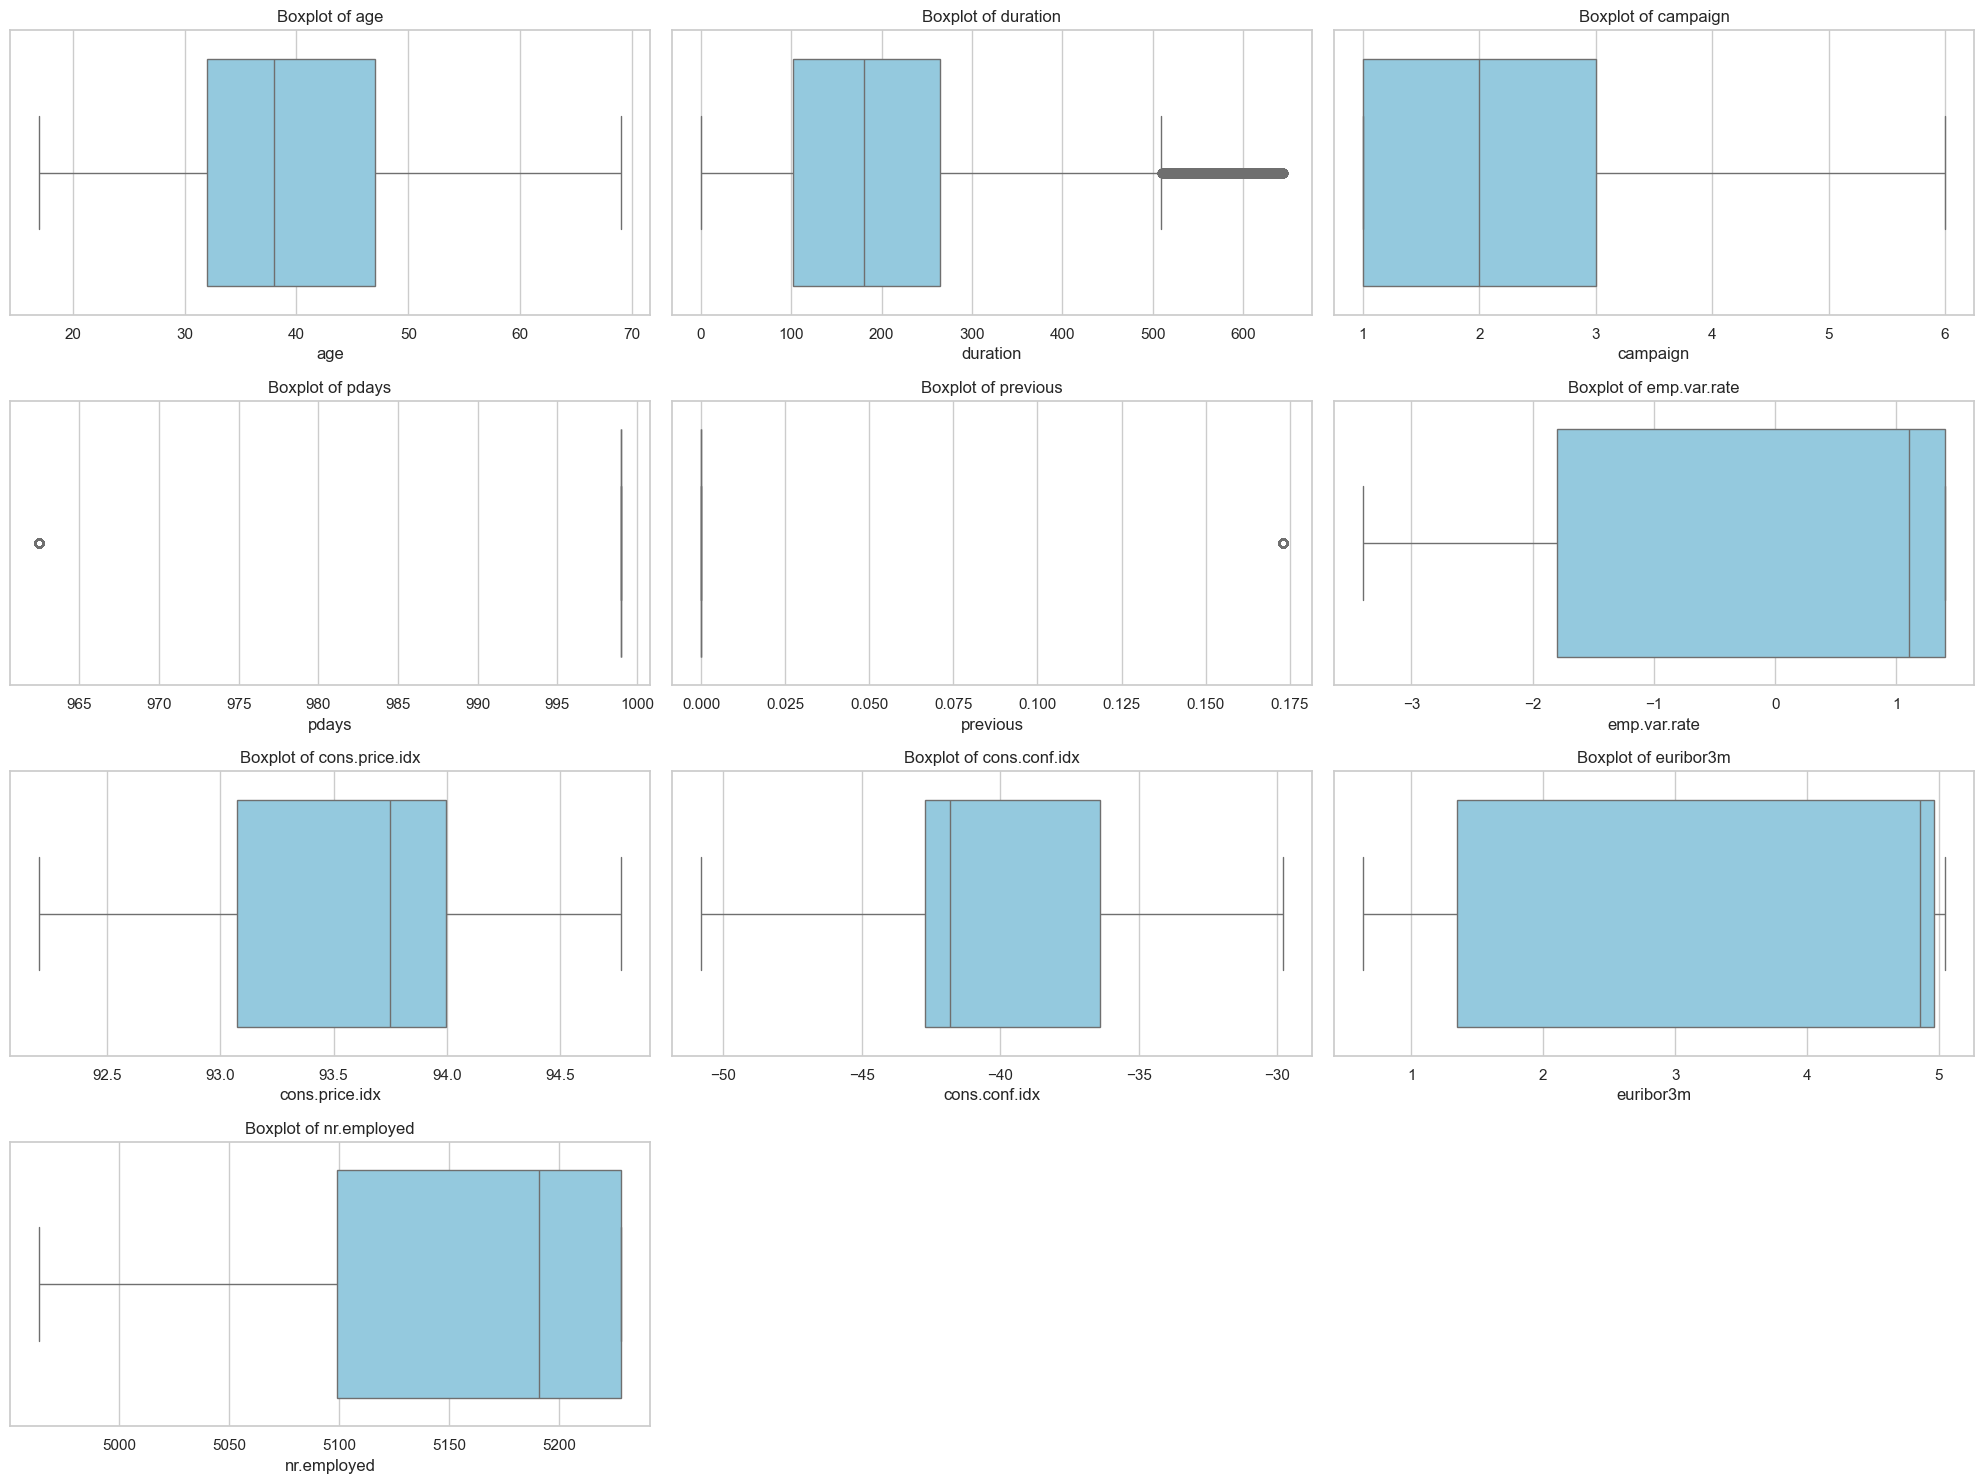

In [5]:
# Set plot style
sns.set(style="whitegrid")

# Plot boxplots for numeric columns
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=data[col], color="skyblue")
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()


In [6]:
# Recalculate IQR and bounds after replacement
for col in numeric_cols:
    Q1_new = data[col].quantile(0.25)
    Q3_new = data[col].quantile(0.75)
    IQR_new = Q3_new - Q1_new
    lower_bound_new = Q1_new - 1.5 * IQR_new
    upper_bound_new = Q3_new + 1.5 * IQR_new

    # Check if replacement values are now outliers
    outliers_after_replacement = data[(data[col] < lower_bound_new) | (data[col] > upper_bound_new)]
    
    if not outliers_after_replacement.empty:
        print(f"Outliers detected again in column {col} after replacement!")

# Optional: Visualizing with boxplots
sns.set(style="whitegrid")


Outliers detected again in column duration after replacement!
Outliers detected again in column pdays after replacement!
Outliers detected again in column previous after replacement!


# After Treatment outlier are there in Numeric Attribute of these three column duration,pdays,previous

Treat Them Again this time Replace with the median()

In [7]:
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median_val = data[col].median()
    
    data[col] = np.where((data[col] < lower_bound) | (data[col] > upper_bound), median_val, data[col])

# Plot the Boxplot

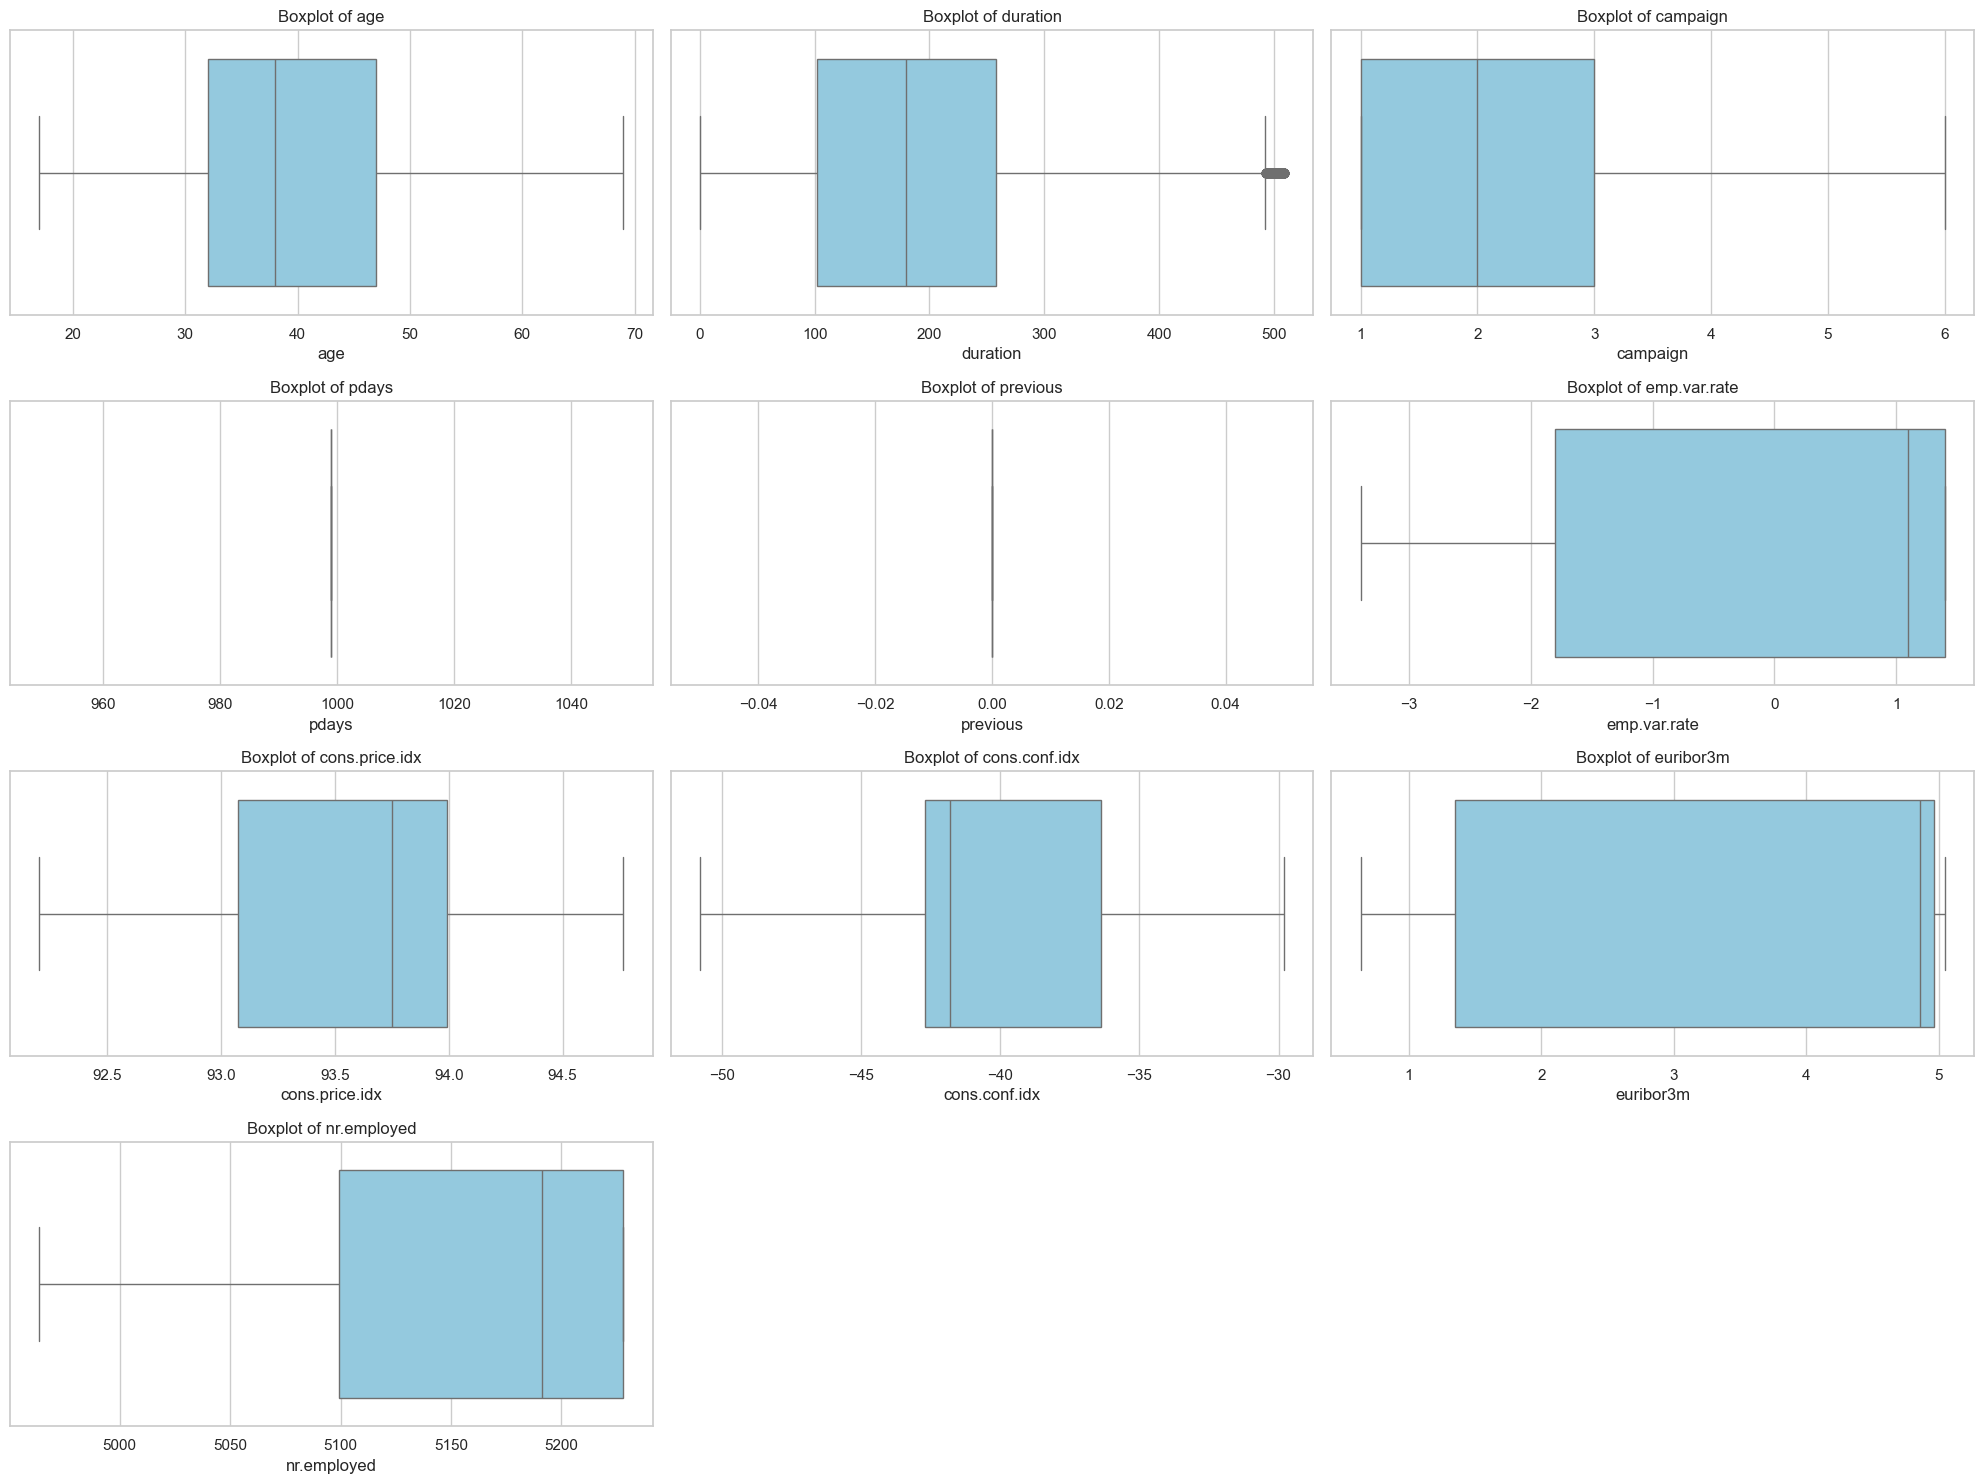

In [8]:
# Set plot style
sns.set(style="whitegrid")

# Plot boxplots for numeric columns
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=data[col], color="skyblue")
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()


In [9]:
# Recalculate IQR and bounds after replacement
for col in numeric_cols:
    Q1_new = data[col].quantile(0.25)
    Q3_new = data[col].quantile(0.75)
    IQR_new = Q3_new - Q1_new
    lower_bound_new = Q1_new - 1.5 * IQR_new
    upper_bound_new = Q3_new + 1.5 * IQR_new

    # Check if replacement values are now outliers
    outliers_after_replacement = data[(data[col] < lower_bound_new) | (data[col] > upper_bound_new)]
    
    if not outliers_after_replacement.empty:
        print(f"Outliers detected again in column {col} after replacement!")

# Optional: Visualizing with boxplots
sns.set(style="whitegrid")


Outliers detected again in column duration after replacement!


# We treated Outlier of Numeric attribute Duration with the mode value

In [10]:
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median_val = data[col].mode()
    
    data[col] = np.where((data[col] < lower_bound) | (data[col] > upper_bound), median_val, data[col])

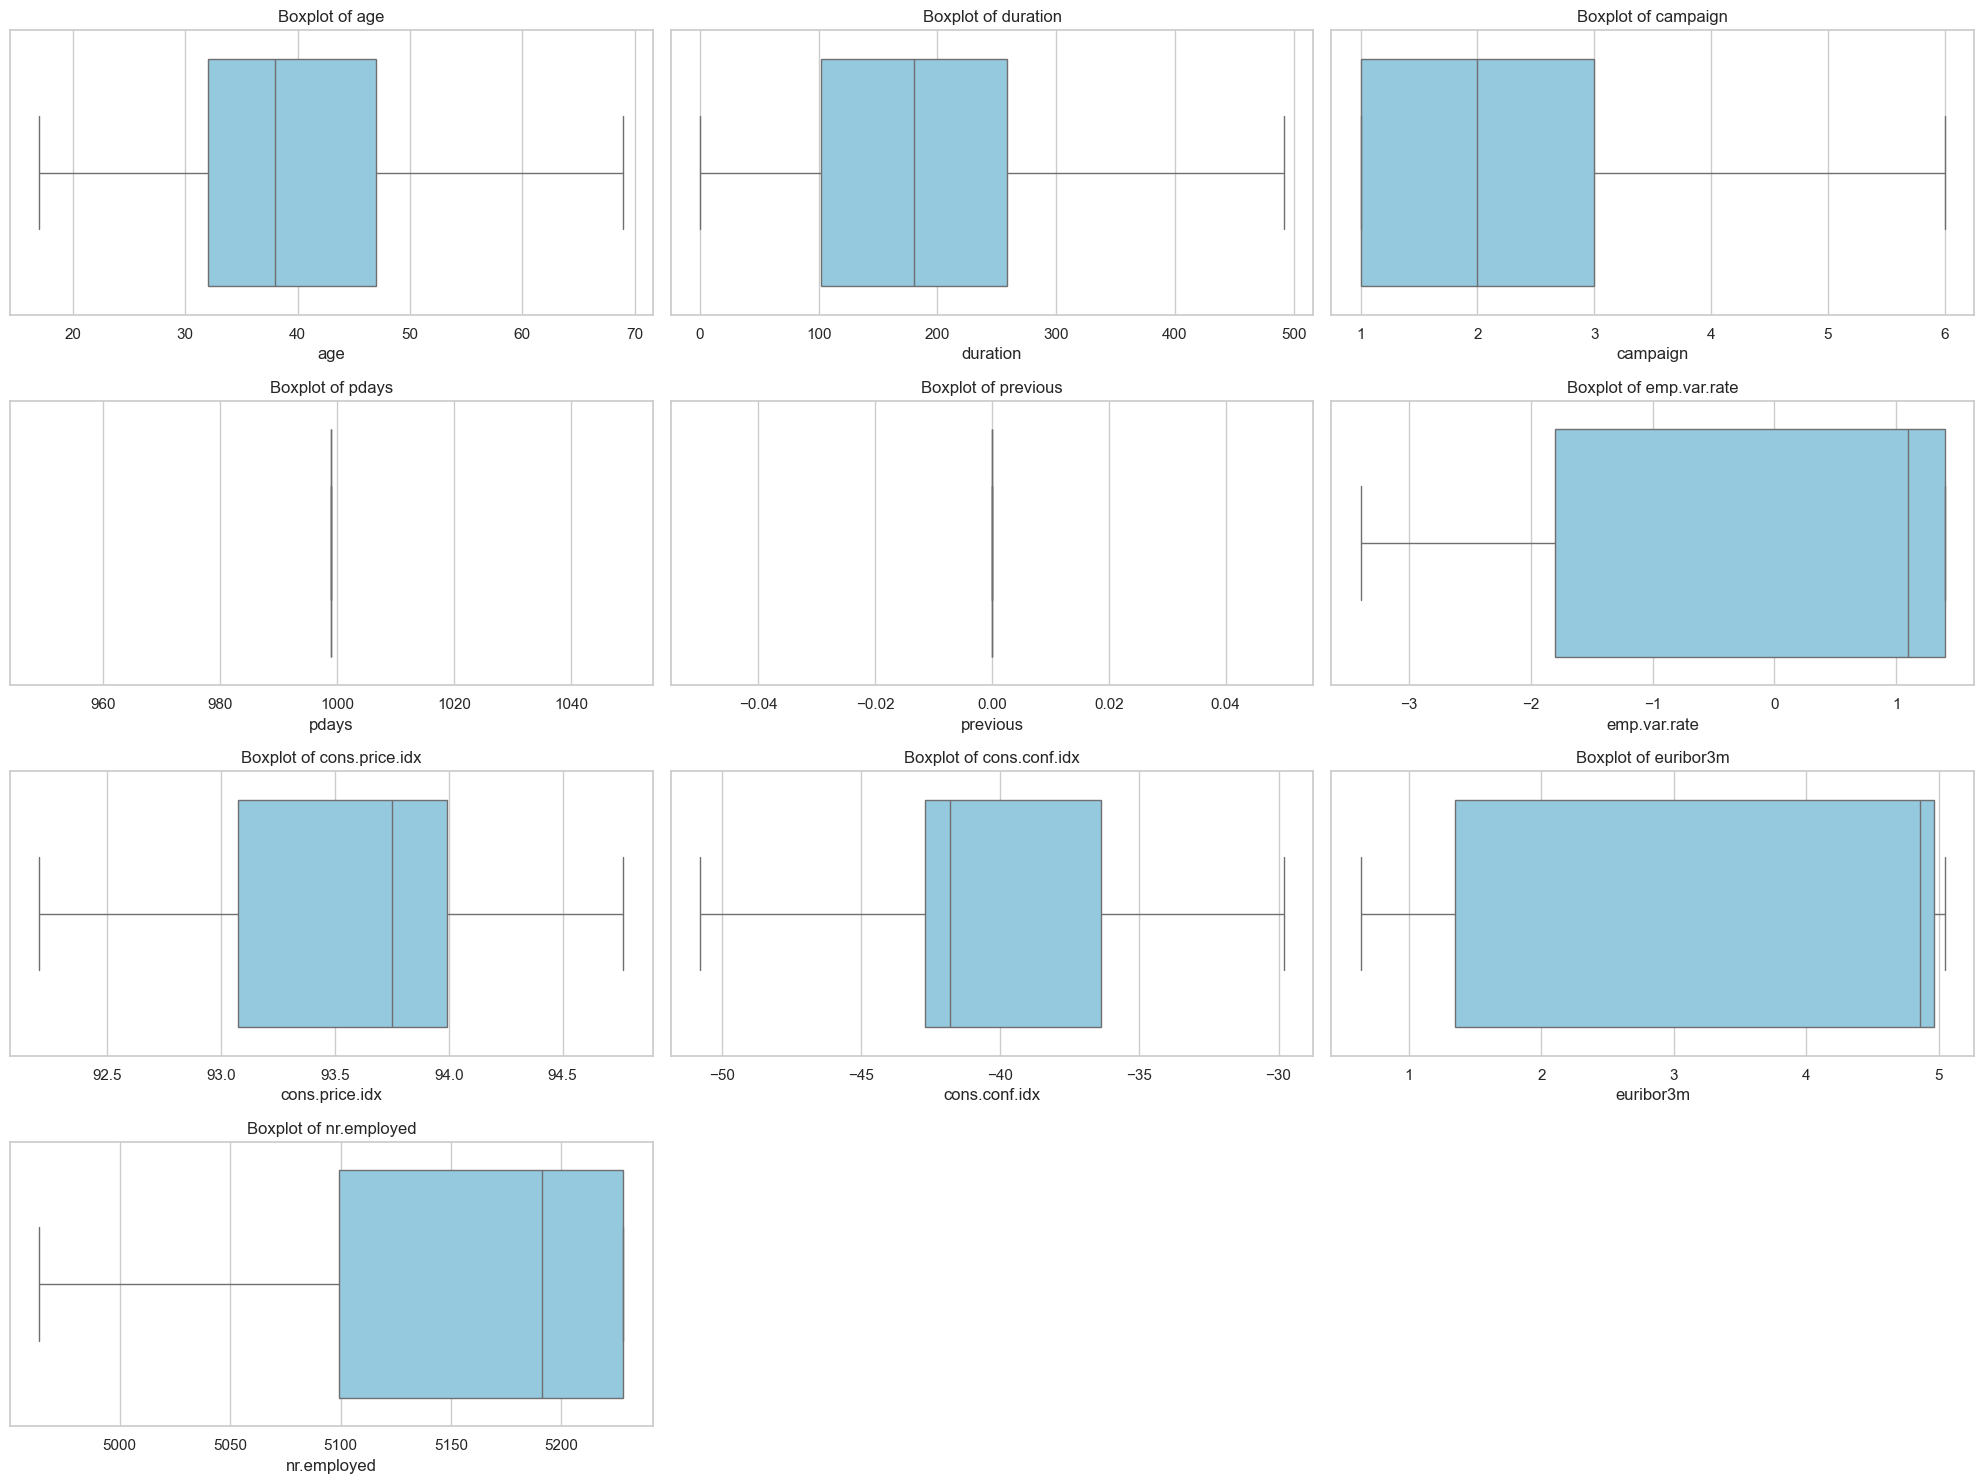

In [11]:
# Set plot style
sns.set(style="whitegrid")

# Plot boxplots for numeric columns
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=data[col], color="skyblue")
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()


In [12]:
# Recalculate IQR and bounds after replacement
for col in numeric_cols:
    Q1_new = data[col].quantile(0.25)
    Q3_new = data[col].quantile(0.75)
    IQR_new = Q3_new - Q1_new
    lower_bound_new = Q1_new - 1.5 * IQR_new
    upper_bound_new = Q3_new + 1.5 * IQR_new

    # Check if replacement values are now outliers
    outliers_after_replacement = data[(data[col] < lower_bound_new) | (data[col] > upper_bound_new)]
    
    if not outliers_after_replacement.empty:
        print(f"Outliers detected again in column {col} after replacement!")
else:
    print("No outliers")
    
# Optional: Visualizing with boxplots
sns.set(style="whitegrid")


No outliers


# Check Unique Values for Categorical Columns

In [13]:
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']:
    print(f"{col} unique values:\n{data[col].value_counts()}\n")


job unique values:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital unique values:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education unique values:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default unique values:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing unique values:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan unique values:
loan
no     

# Visualize Numerical Data Distributions

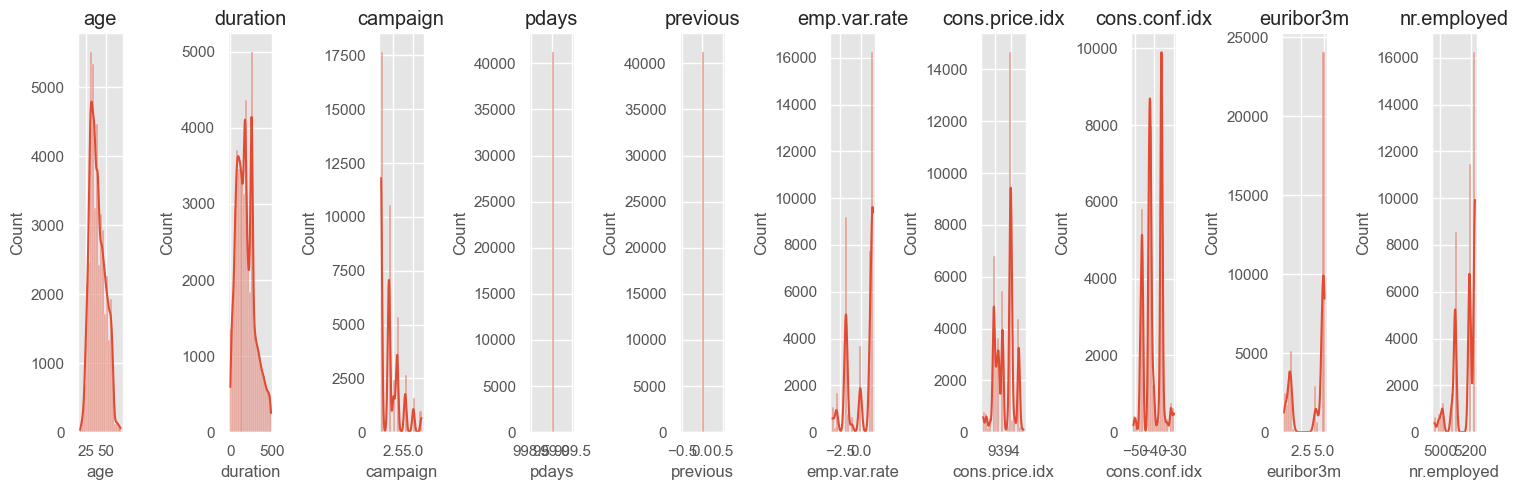

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use("ggplot")

# Create histograms for numerical variables
fig, axes = plt.subplots(nrows=1, ncols=len(data.select_dtypes(include="number").columns), figsize=(15, 5))

for i, column in enumerate(data.select_dtypes(include="number").columns):
    sns.histplot(data[column], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

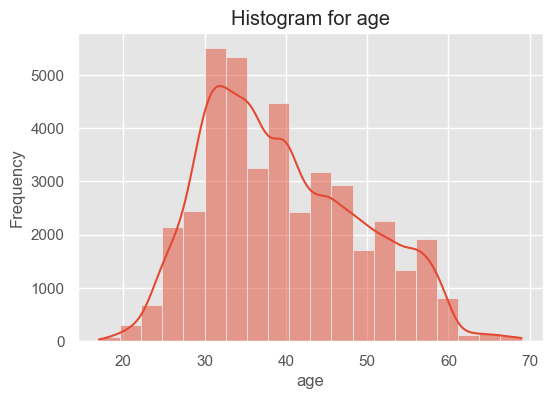

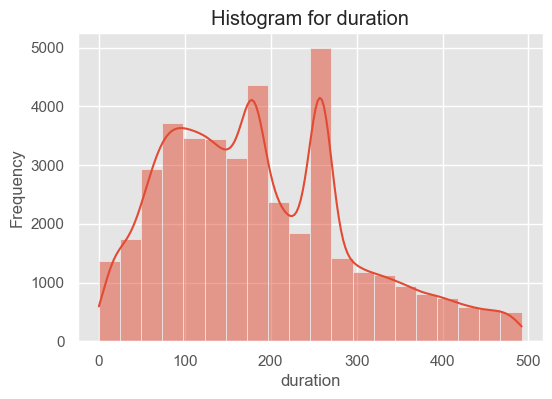

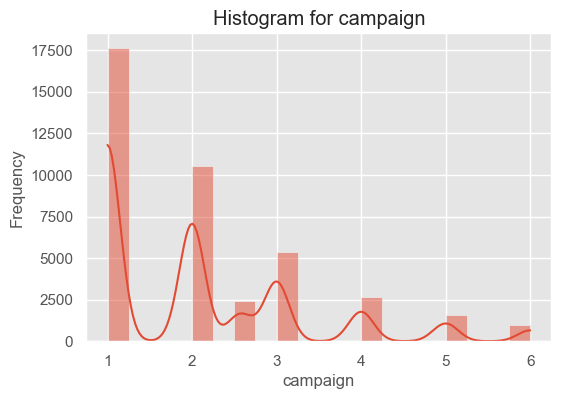

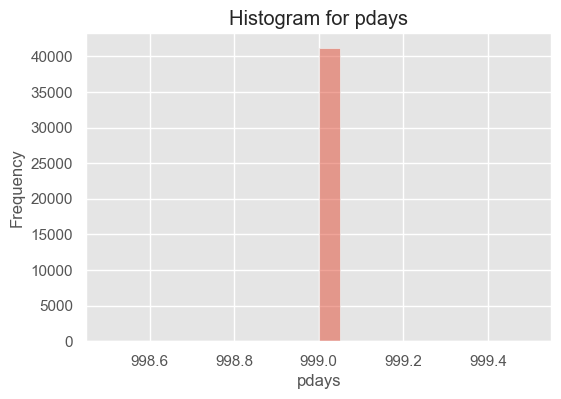

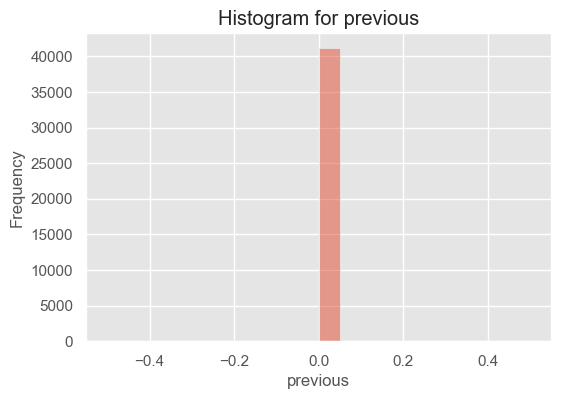

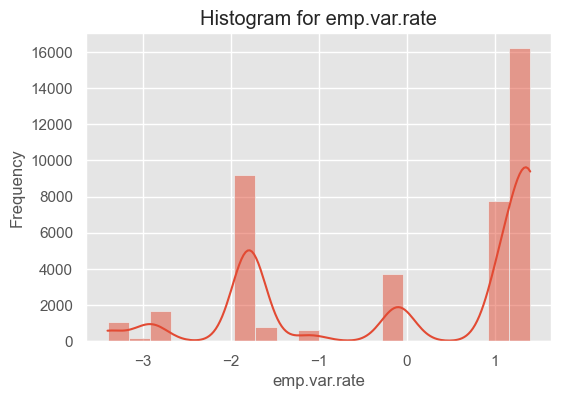

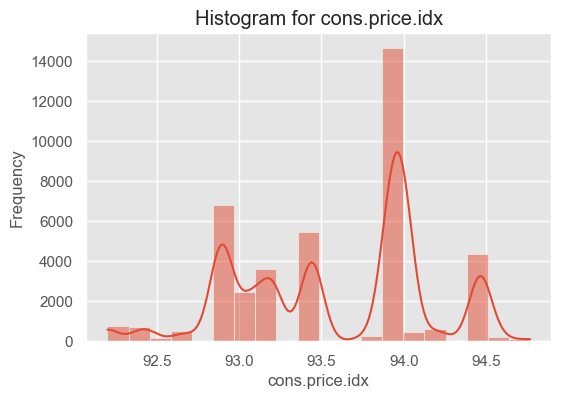

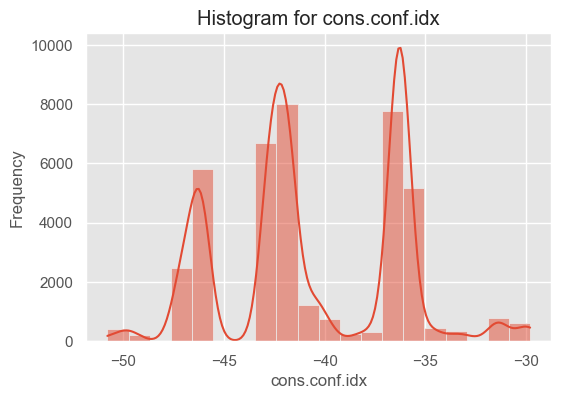

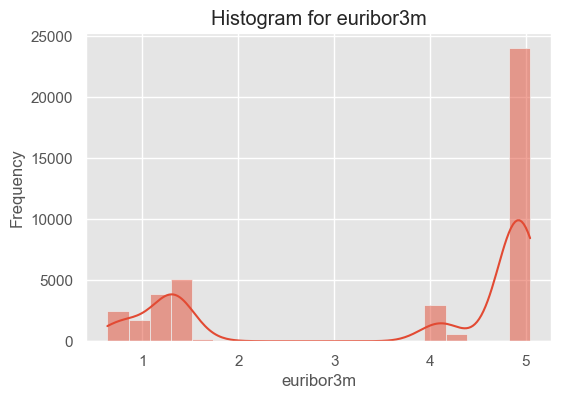

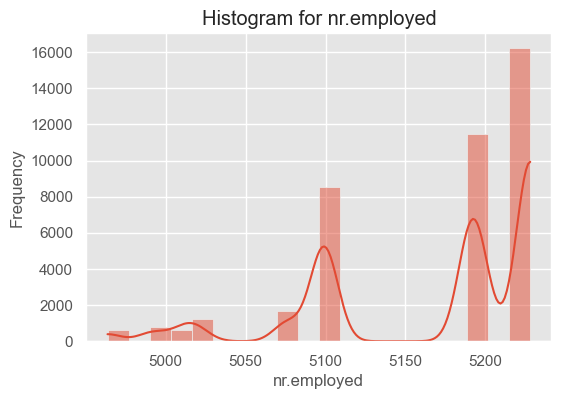

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = data.select_dtypes(include="number").columns

# Loop through each numerical column
for column in num_cols:
    plt.figure(figsize=(6, 4))  # Create a new figure for each histogram
    sns.histplot(data[column], bins=20, kde=True)  # Histogram with KDE overlay
    plt.title(f"Histogram for {column}")  # Set title
    plt.xlabel(column)  # Label x-axis
    plt.ylabel("Frequency")  # Label y-axis
    plt.show()  # Display the plot

Has pday and previous has same value in the data which i think it don't really help for analysis we can either ignore them or remove them if it is not important 

Seeing the categorical key attribute 'y'

C:\Users\joyst\AppData\Local\Temp\ipykernel_11424\3869128373.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=data, palette='viridis')


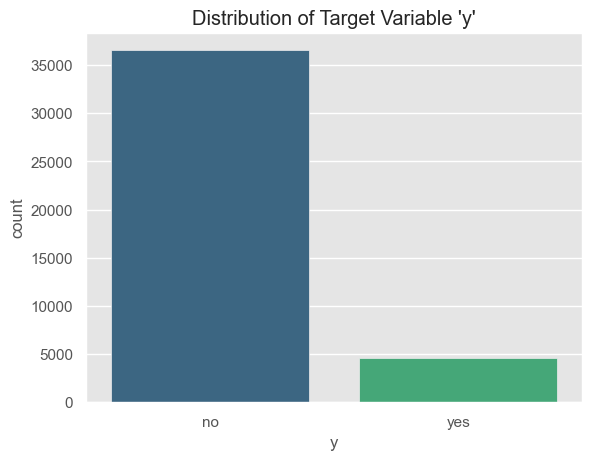

In [16]:
sns.countplot(x='y', data=data, palette='viridis')
plt.title("Distribution of Target Variable 'y'")
plt.show()


#  Check Relationship Between Categorical Features and 'y' after the treatment of outliers

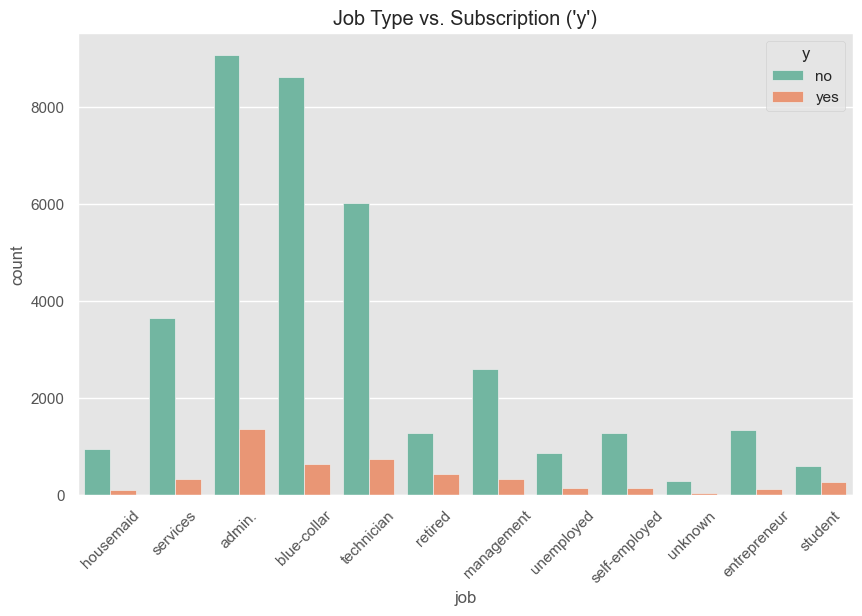

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(x='job', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Job Type vs. Subscription ('y')")
plt.show()


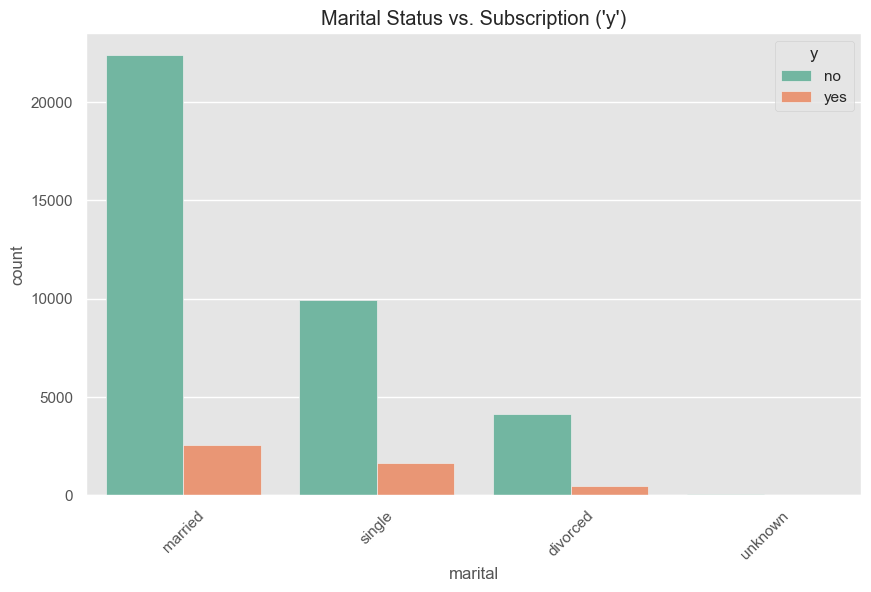

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(x='marital', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Marital Status vs. Subscription ('y')")
plt.show()

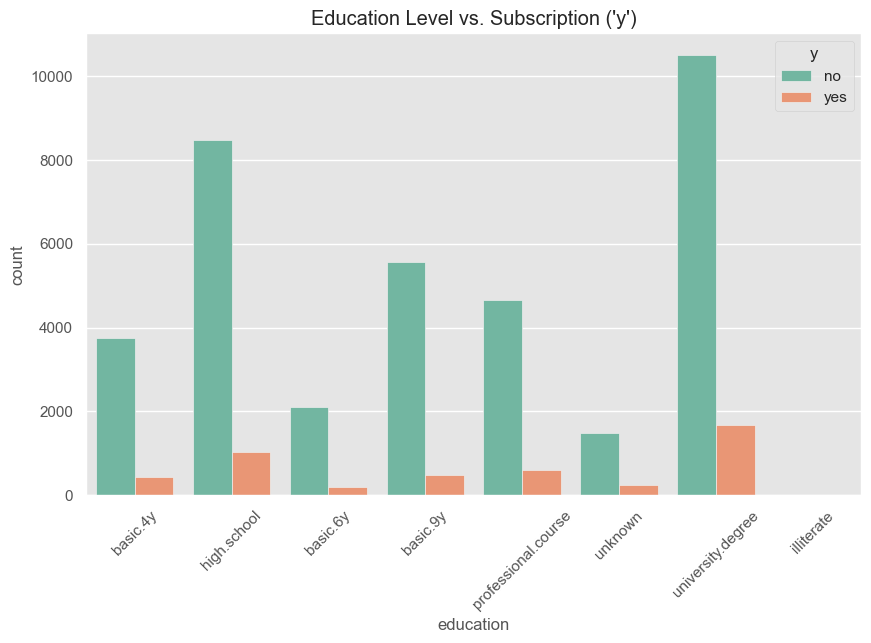

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='education', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Education Level vs. Subscription ('y')")
plt.show()

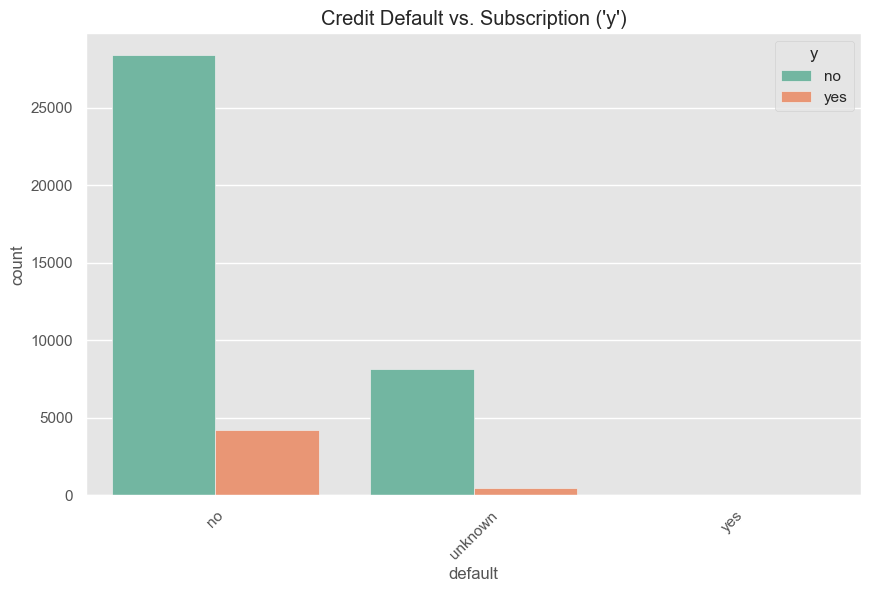

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='default', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Credit Default vs. Subscription ('y')")
plt.show()

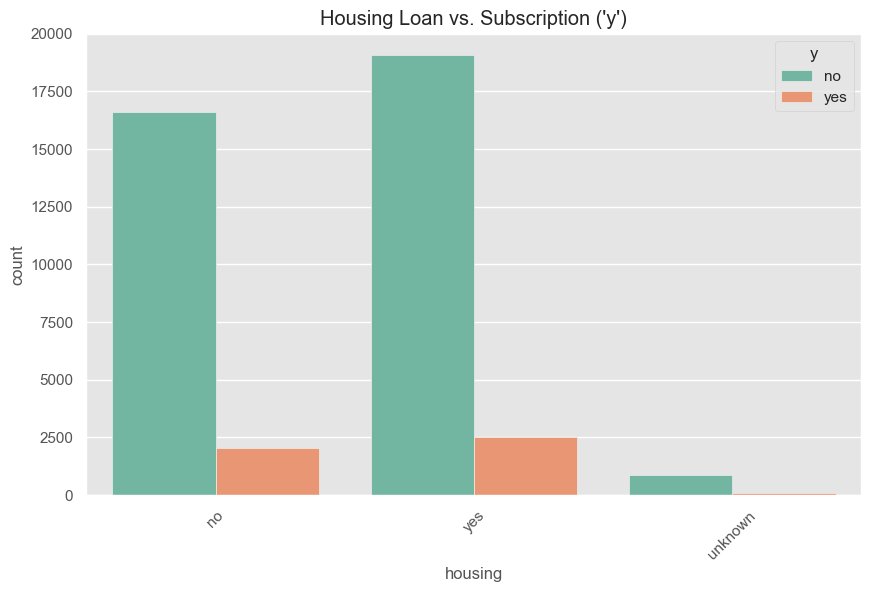

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x='housing', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Housing Loan vs. Subscription ('y')")
plt.show()


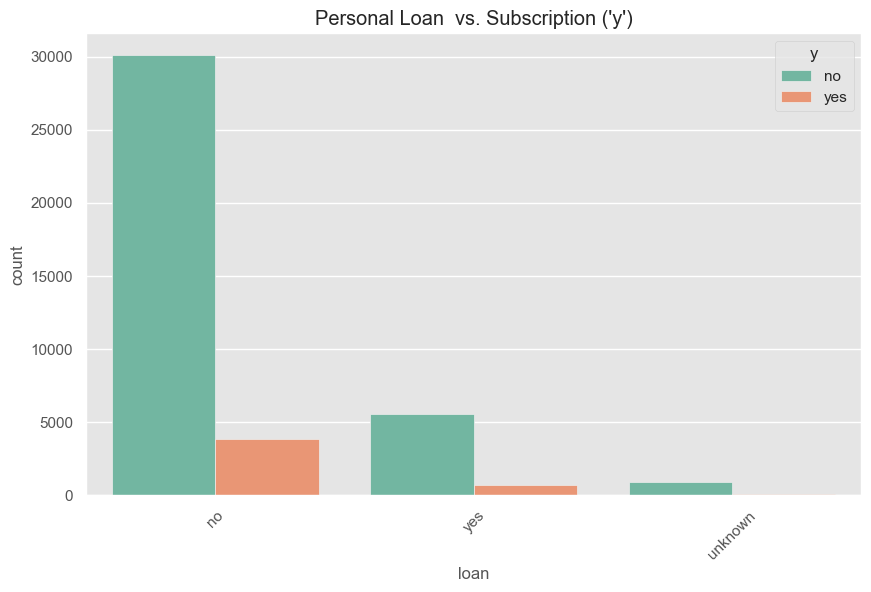

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(x='loan', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Personal Loan  vs. Subscription ('y')")
plt.show()


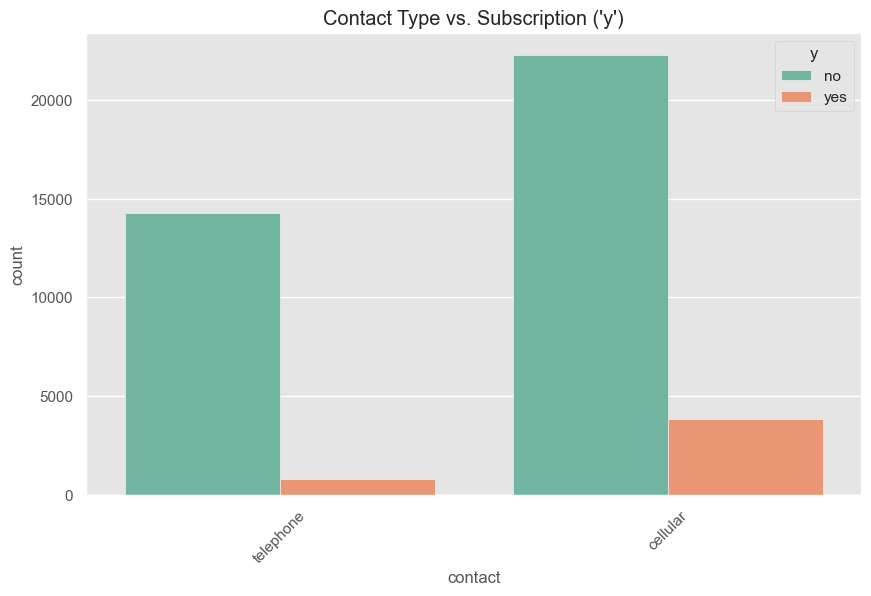

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(x='contact', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Contact Type vs. Subscription ('y')")
plt.show()


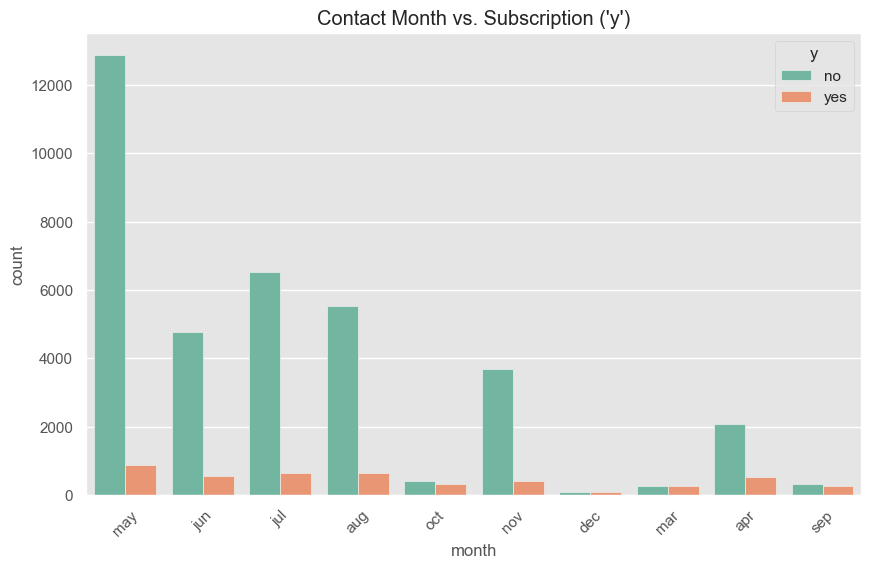

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(x='month', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Contact Month vs. Subscription ('y')")
plt.show()


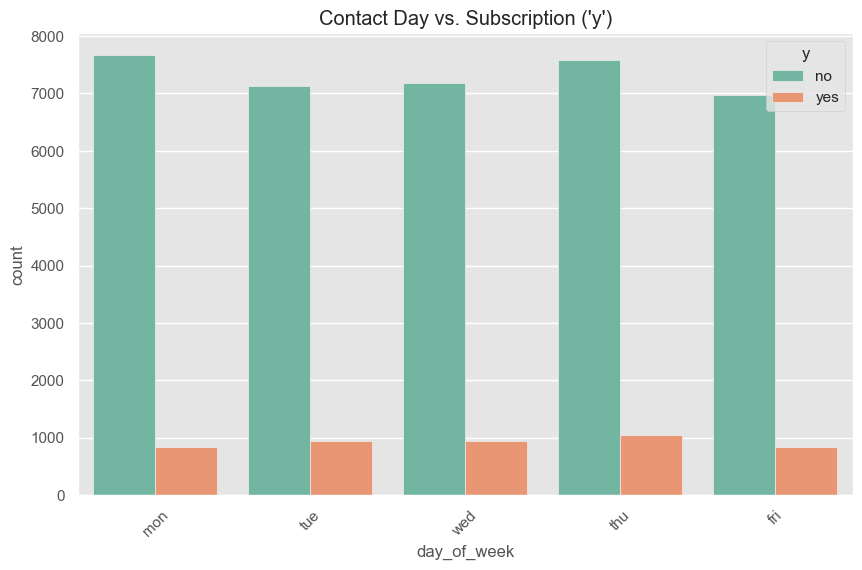

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(x='day_of_week', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Contact Day vs. Subscription ('y')")
plt.show()

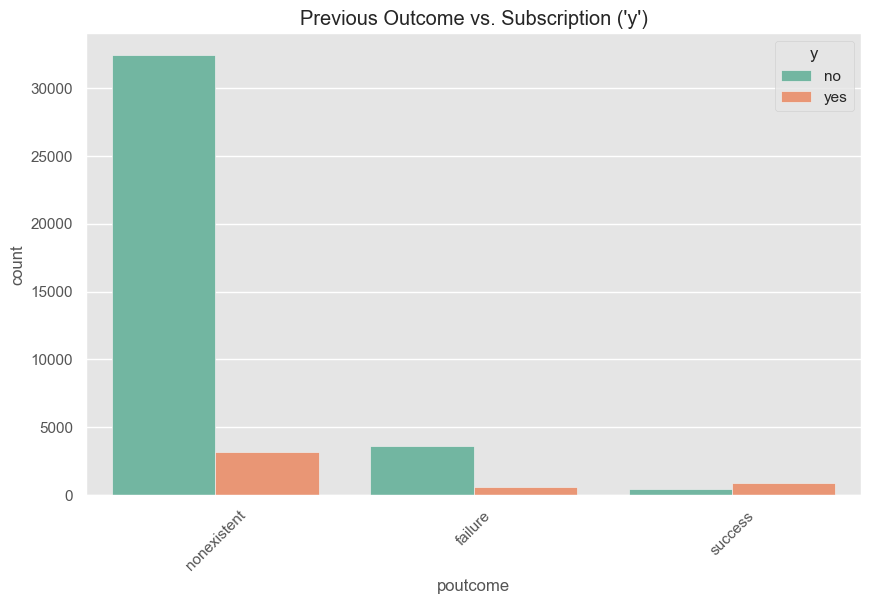

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(x='poutcome', hue='y', data=data, palette='Set2')
plt.xticks(rotation=45)
plt.title("Previous Outcome vs. Subscription ('y')")
plt.show()


# Analyze Duration of Calls (Key Predictor)

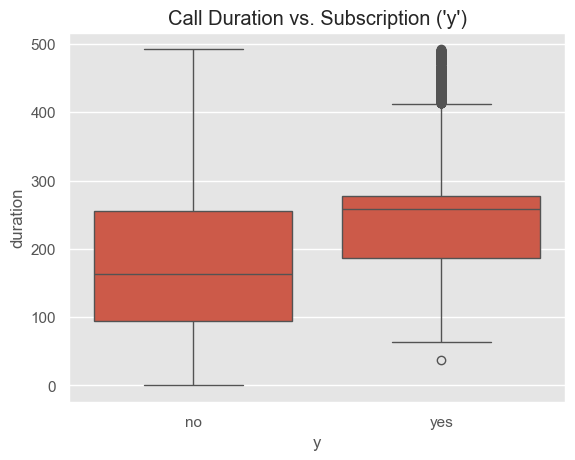

In [27]:
sns.boxplot(x='y', y='duration', data=data)
plt.title("Call Duration vs. Subscription ('y')")
plt.show()


In [28]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['duration'].quantile(0.25)
Q3 = data['duration'].quantile(0.75)
IQR = Q3 - Q1  # Interquartile Range

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data[(data['duration'] < lower_bound) | (data['duration'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 0


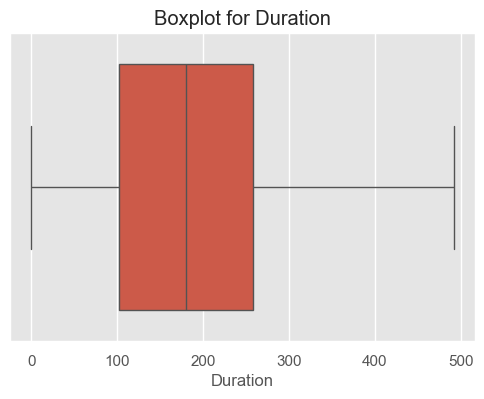

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for 'duration'
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x='duration')  # Plot the boxplot
plt.title("Boxplot for Duration")  # Title for the plot
plt.xlabel("Duration")  # Label for x-axis
plt.show()  # Display the boxplot

In [30]:
# Calculate IQR for each group
grouped_stats = data.groupby('y')['duration'].describe()
print(grouped_stats)

for group in data['y'].unique():
    Q1 = data[data['y'] == group]['duration'].quantile(0.25)
    Q3 = data[data['y'] == group]['duration'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"Group {group}: Lower Bound = {lower_bound}, Upper Bound = {upper_bound}")

       count        mean         std   min    25%        50%     75%    max
y                                                                          
no   36548.0  179.438354  108.384356   0.0   95.0  163.50000  255.25  492.0
yes   4640.0  258.780177   85.053441  37.0  187.0  258.28501  277.00  492.0
Group no: Lower Bound = -145.375, Upper Bound = 495.625
Group yes: Lower Bound = 52.0, Upper Bound = 412.0


In [31]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import Counter

# Load data
data = pd.read_csv('bankmarketing.csv')
data['y'] = data['y'].map({'yes': 1, 'no': 0})  # Encode target if needed

# Separate features and target
X = data.drop('y', axis=1)
y = data['y']

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Check original counts
print("Before SMOTE:", Counter(y_train))

# Calculate the number of minority samples needed for a 70:30 ratio
majority_class_count = Counter(y_train)[0]
target_minority_count = int((30 / 70) * majority_class_count)

sampling_strategy = {1: target_minority_count}  # '1' is the minority class

# Apply SMOTE with custom ratio
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Check new balance
print("After SMOTE:", Counter(y_train_bal))


Before SMOTE: Counter({0: 29238, 1: 3712})
After SMOTE: Counter({0: 29238, 1: 12530})


C:\Users\joyst\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\joyst\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [32]:
# Convert balanced class counts to percentages
total_balanced = sum(Counter(y_train_bal).values())
balanced_percentages = {cls: f"{count / total_balanced * 100:.2f}%" 
                        for cls, count in Counter(y_train_bal).items()}

print("Balanced training set distribution (percentages):", balanced_percentages)


Balanced training set distribution (percentages): {0: '70.00%', 1: '30.00%'}


# Analyze Trends Over Time

C:\Users\joyst\AppData\Local\Temp\ipykernel_11424\539916539.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='month', y='duration', data=data, estimator='mean', ci=None)


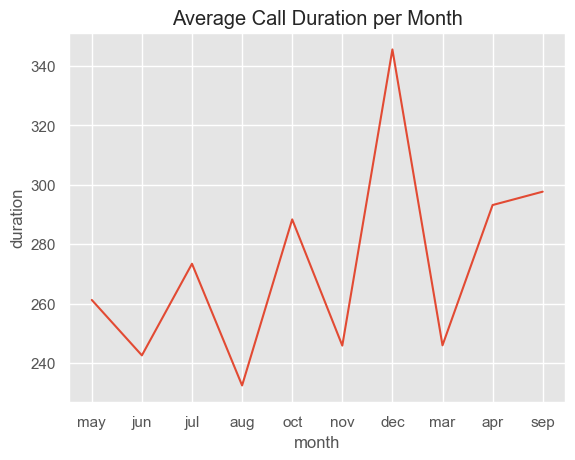

In [33]:
sns.lineplot(x='month', y='duration', data=data, estimator='mean', ci=None)
plt.title("Average Call Duration per Month")
plt.show()

C:\Users\joyst\AppData\Local\Temp\ipykernel_11424\406195600.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='day_of_week', y='duration', data=data, estimator='mean', ci=None)


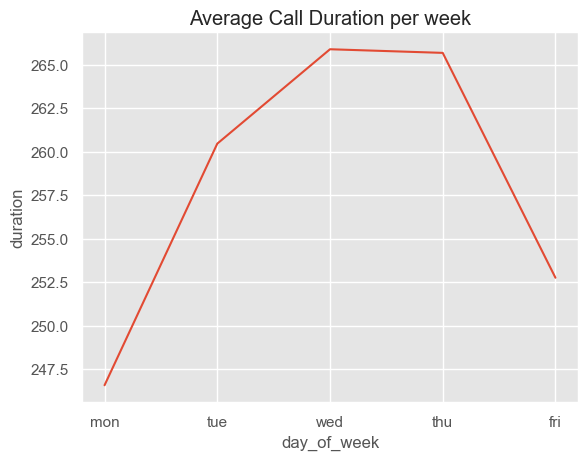

In [34]:
sns.lineplot(x='day_of_week', y='duration', data=data, estimator='mean', ci=None)
plt.title("Average Call Duration per week")
plt.show()